In [13]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, recall_score, precision_score, f1_score,
    average_precision_score,
)
import shap
import joblib
import matplotlib.pyplot as plt

# Resolve data directory (repo has `Data/`, not `data/`)
# Jupyter can run with cwd = `Notebook/`, so search upward from cwd.

def find_data_dir() -> Path:
    candidates = ['Data', 'data']
    for base in [Path.cwd(), *Path.cwd().parents]:
        for name in candidates:
            p = base / name
            if p.exists() and p.is_dir():
                return p
    raise FileNotFoundError(
        "Could not find OULAD CSV folder. Tried searching for: "
        + ", ".join(candidates)
        + f" under cwd={Path.cwd()} and its parents."
    )

data_dir = find_data_dir()
print('Using data_dir:', data_dir)

# Loading relevant tables
student_info = pd.read_csv(data_dir / 'studentInfo.csv')
student_vle = pd.read_csv(data_dir / 'studentVle.csv')
student_assessment = pd.read_csv(data_dir / 'studentAssessment.csv')
assessments = pd.read_csv(data_dir / 'assessments.csv')




Using data_dir: /Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/Data


,The Oulad dataset is relational so we need to load the different datasets and merge them together
we start from the studentInfo as the base table
aggregate StudentVle to student level
merge studentAssessment with assessments
aggregate assessment data to student level
merge engineered features back into studentInfo
,


In [14]:
#creating the target variable
student_info['at_risk'] = student_info['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)

#early days is the time limit in which the model can access to come up with a result as we are chasing early intervention so we filter out the results after 30 days
early_days = 30
early_vle = student_vle[student_vle['date'] <= early_days]

# features for the learning environment
vle_features = (
    early_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        total_clicks=('sum_click', 'sum'),
        avg_clicks=('sum_click', 'mean'),
        vle_records=('sum_click', 'count')
    )
    .reset_index()
)

# full assessment details
assessment_full = student_assessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

# we do the same filtering process for the assessment data we merge and then filter for the first 30 days
early_assessments = assessment_full[assessment_full['date_submitted'] <= early_days]

assessment_features = (
    early_assessments
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        avg_score=('score', 'mean'),
        total_score=('score', 'sum'),
        assessment_count=('score', 'count'),
        avg_weight=('weight', 'mean'),
    )
    .reset_index()
)

#merge all tables into one
df = student_info.merge(
    vle_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

df = df.merge(
    assessment_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)


Handling missing values

In [15]:
#handling nulls
print('Before Handling' ,df.isnull().sum())

#fill nulls with 0 where it makes sense
feature_cols = [
    'total_clicks',
    'avg_clicks',
    'vle_records',
    'avg_score',
    'total_score',
    'assessment_count',
    'avg_weight',
]

#fill all numerical columns with 0
df[feature_cols] = df[feature_cols].fillna(0)
#fill imd_band which is a categorical column with 'Unknown'
df['imd_band'] = df['imd_band'].fillna('Unknown')

print('\nAfter Handling',df.isnull().sum())




#dropping final column to ensure no data leakage, student id is kept in place for grouped splitting
df = df.drop(columns=['final_result'])


#So i am creating two datasets for comparison between two models one with the module code and one without the module code
df_with_module = df.copy()
df_without_module = df.drop(columns=['code_module'])


Before Handling code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
at_risk                     0
total_clicks             3751
avg_clicks               3751
vle_records              3751
avg_score               11302
total_score             11289
assessment_count        11289
avg_weight              11289
dtype: int64

After Handling code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
at_risk                 0
total_clicks     

Encoding and Machine learning stage

In [16]:


# turned the training and evaluation into one reusable function so i can compare models with and without certain features
def train_and_evaluate(df_input, model, model_name):
    x = df_input.drop(columns=['at_risk'])
    y = df_input['at_risk']

    #Using student id for grouped splitting
    groups = df_input['id_student']

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(x, y, groups=groups))

    x_train = x.iloc[train_idx].copy()
    x_test = x.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    #dropping student id after splitting so it is not used as a feature
    x_train = x_train.drop(columns=['id_student'])
    x_test = x_test.drop(columns=['id_student'])

    #encoding after splitting
    x_train = pd.get_dummies(x_train, drop_first=True)
    x_test = pd.get_dummies(x_test, drop_first=True)

    #align columns
    x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

    #clean column names for XGBoost compatability
    x_train.columns = x_train.columns.str.replace(r'[\[\]<]', '', regex=True)
    x_test.columns = x_test.columns.str.replace(r'[\[\]<]', '', regex=True)

    #handle class imbalance (only applies to XGBoost)
    if isinstance(model, XGBClassifier):
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        if pos > 0:
            model.set_params(scale_pos_weight=neg / pos)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    #metrics
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    #ROC curve
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    #feature importance for XGBoost
    importance_df = None
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": x_train.columns,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)

        print("\nTop 15 Features:")
        print(importance_df.head(15))

        importance_df.head(15).sort_values("importance").plot(
            x="feature",
            y="importance",
            kind="barh",
            figsize=(10, 6)
        )
        plt.title(f"Top 15 Features - {model_name}")
        plt.show()

    return model, importance_df

#baseline model
lr_model = LogisticRegression(max_iter=3000,solver='liblinear' ,random_state=42)

#xgb model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)




Evaluate the model


Logistic Regression WITH module
Accuracy: 0.7451707618606088
ROC-AUC: 0.8306335611748417
PR-AUC: 0.8663286704916937
Precision: 0.7726847521047708
Recall: 0.7292525014714538
F1: 0.750340651021953

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74      3073
           1       0.77      0.73      0.75      3398

    accuracy                           0.75      6471
   macro avg       0.75      0.75      0.75      6471
weighted avg       0.75      0.75      0.75      6471



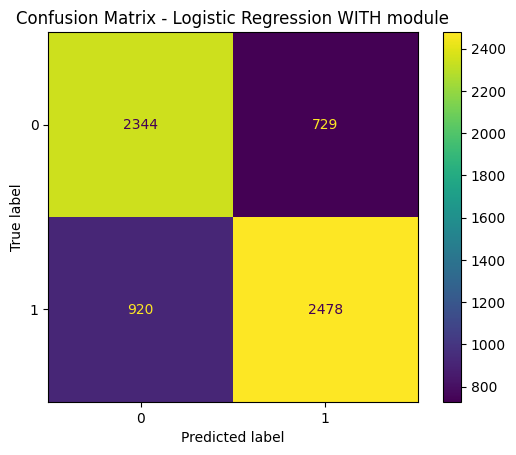

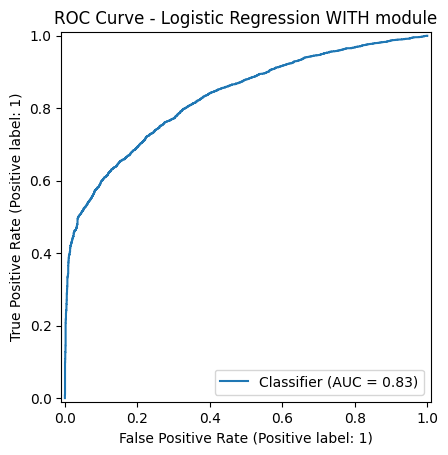


XGBoost WITH module
Accuracy: 0.760160717045279
ROC-AUC: 0.8429235761469918
PR-AUC: 0.878248254995107
Precision: 0.8191562932226832
Recall: 0.6971748087110065
F1: 0.7532591414944356

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.77      3073
           1       0.82      0.70      0.75      3398

    accuracy                           0.76      6471
   macro avg       0.77      0.76      0.76      6471
weighted avg       0.77      0.76      0.76      6471



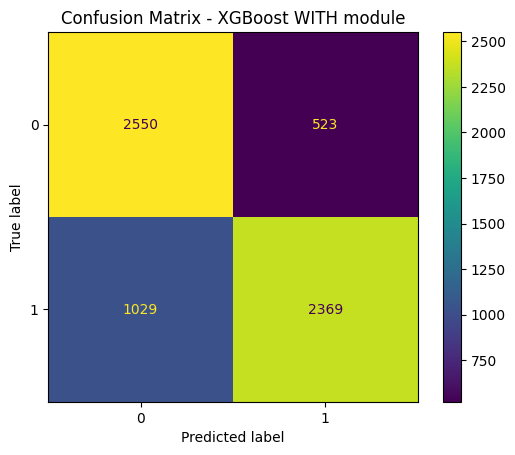

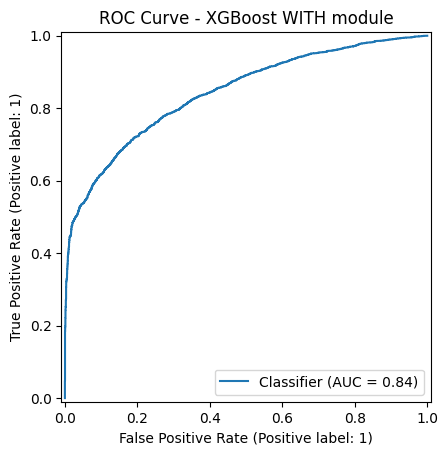


Top 15 Features:
                                 feature  importance
12                       code_module_EEE    0.167426
14                       code_module_GGG    0.135135
5                              avg_score    0.109549
4                            vle_records    0.057475
7                       assessment_count    0.044515
9                        code_module_BBB    0.040284
13                       code_module_FFF    0.033278
10                       code_module_CCC    0.030756
11                       code_module_DDD    0.024883
32  highest_education_Lower Than A Level    0.023596
2                           total_clicks    0.020981
0                   num_of_prev_attempts    0.016972
6                            total_score    0.014610
44                      imd_band_Unknown    0.014236
8                             avg_weight    0.013072


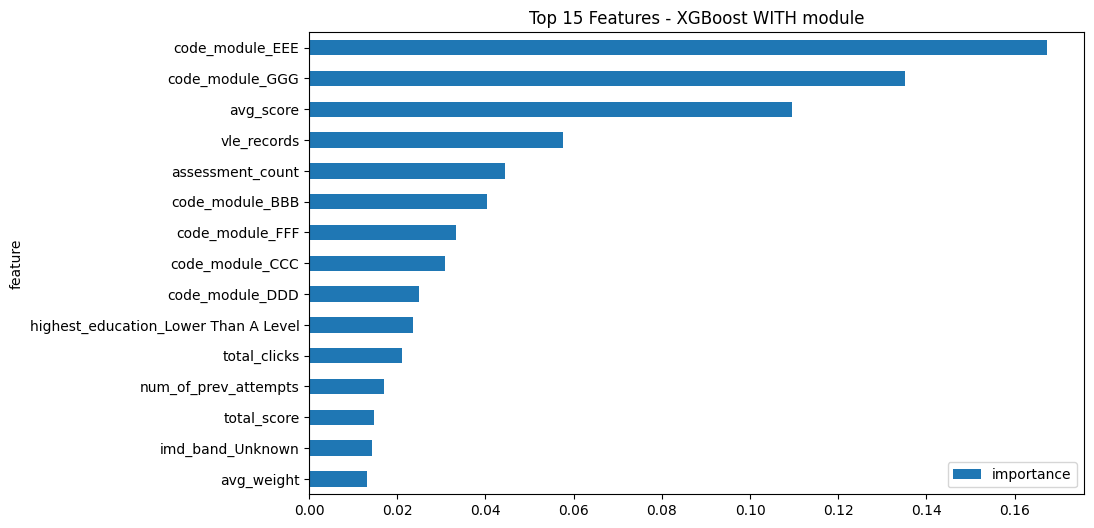


Logistic Regression WITHOUT module
Accuracy: 0.7141091021480451
ROC-AUC: 0.8015819971817805
PR-AUC: 0.8339535789054251
Precision: 0.727781047675103
Recall: 0.727781047675103
F1: 0.727781047675103

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70      3073
           1       0.73      0.73      0.73      3398

    accuracy                           0.71      6471
   macro avg       0.71      0.71      0.71      6471
weighted avg       0.71      0.71      0.71      6471



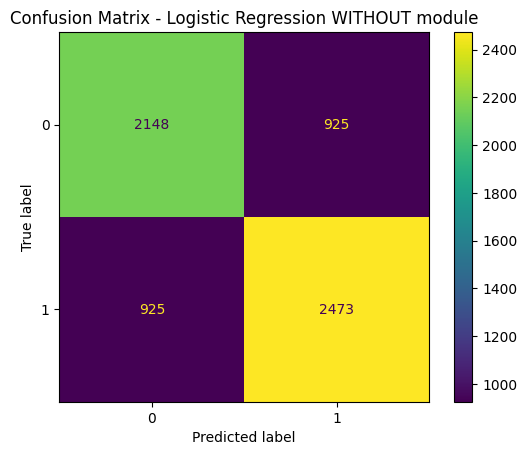

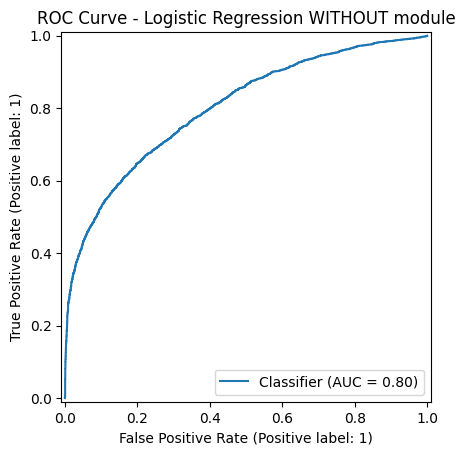


XGBoost WITHOUT module
Accuracy: 0.7499613660948848
ROC-AUC: 0.8354614427391394
PR-AUC: 0.8689573048303013
Precision: 0.8035470668485676
Recall: 0.6933490288404944
F1: 0.744391785150079

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.81      0.76      3073
           1       0.80      0.69      0.74      3398

    accuracy                           0.75      6471
   macro avg       0.75      0.75      0.75      6471
weighted avg       0.76      0.75      0.75      6471



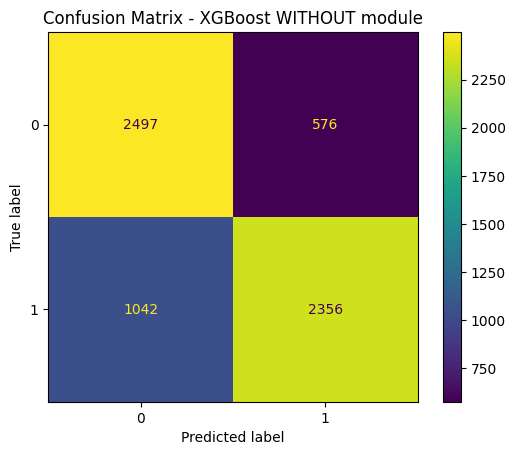

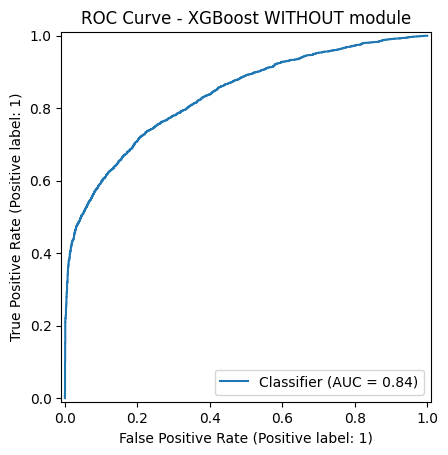


Top 15 Features:
                                 feature  importance
5                              avg_score    0.160503
4                            vle_records    0.090819
1                        studied_credits    0.059661
7                       assessment_count    0.050815
2                           total_clicks    0.041163
26  highest_education_Lower Than A Level    0.039224
8                             avg_weight    0.039161
0                   num_of_prev_attempts    0.035488
38                      imd_band_Unknown    0.026365
41                          disability_Y    0.022045
11               code_presentation_2014J    0.021604
12                              gender_M    0.021006
6                            total_score    0.020770
37                      imd_band_90-100%    0.019149
27     highest_education_No Formal quals    0.018558


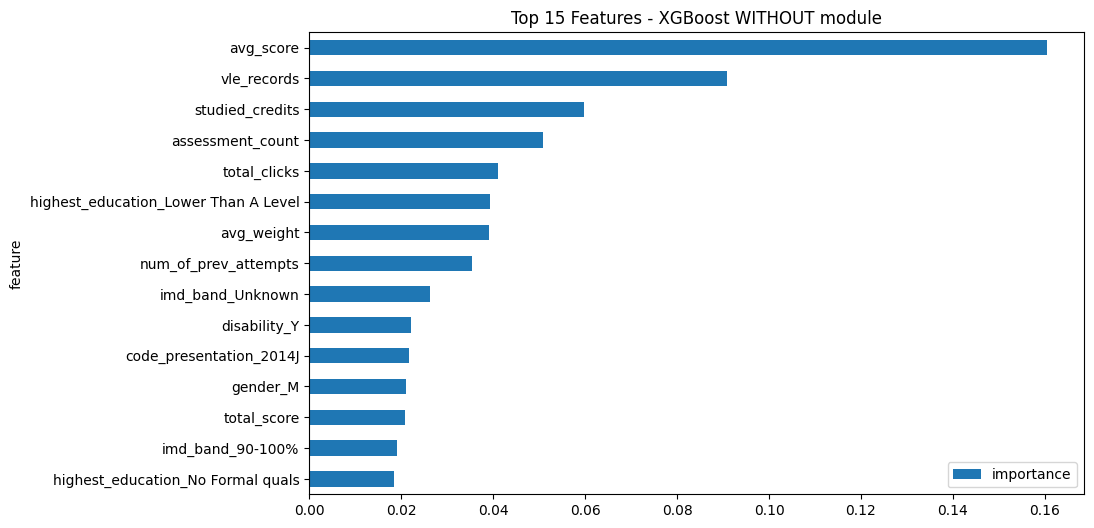

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=200,
               n_jobs=None, num_parallel_tree=None, ...),
                                           feature  importance
 5                                       avg_score    0.160503
 4                                     vle_records    0.090819
 1                                 studied

In [17]:
train_and_evaluate(df_with_module, lr_model, "Logistic Regression WITH module")
train_and_evaluate(df_with_module, xgb_model, "XGBoost WITH module")

train_and_evaluate(df_without_module, lr_model, "Logistic Regression WITHOUT module")
train_and_evaluate(df_without_module, xgb_model, "XGBoost WITHOUT module")

Creating the sample dataset

In [18]:
at_risk_df = df_without_module[df_without_module['at_risk'] == 1]
not_at_risk_df = df_without_module[df_without_module['at_risk'] == 0]

at_risk_sample = at_risk_df.sample(n=100 , random_state=42)
not_at_risk_sample = not_at_risk_df.sample(n = 100 , random_state=42)

demo_df = pd.concat([at_risk_sample, not_at_risk_sample]).sample(frac=1,random_state=42).reset_index(drop=True)

print(demo_df.shape)
print(demo_df['at_risk'].value_counts())


columns_to_keep = [
    'id_student',
    'gender',
    'age_band',
    'highest_education',
    'imd_band',
    'num_of_prev_attempts',
    'studied_credits',
    'disability',
    'region',
    'code_presentation',
    'total_clicks',
    'avg_clicks',
    'vle_records',
    'avg_score',
    'assessment_count',
    'at_risk'
]

demo_df = demo_df[columns_to_keep]

# saved the results to a csv file
#demo_df.to_csv("demo_students.csv", index=False)

(200, 18)
at_risk
1    100
0    100
Name: count, dtype: int64


training final model for deployment

In [19]:
def train_final_model(df_input):
    x = df_input.drop(columns=['at_risk']).copy()
    y = df_input['at_risk'].copy()

    #we drop student id because it is only for ui purposes
    x = x.drop(columns=['id_student'])

    #ENCODING
    x = pd.get_dummies(x, drop_first=True)

    #cleaning column names
    x.columns = x.columns.str.replace(r'[\[\]<]', '', regex=True)

    #class imbalance handling
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    spw = (neg / pos) if pos > 0 else 1.0

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        scale_pos_weight=spw,
    )

    model.fit(x, y)

    return model, x.columns.tolist()

final_model, feature_cols = train_final_model(df_without_module)

# Export artifacts to match backend expectations
# Save into the repo-root `model/` even if notebook cwd is `Notebook/`

def find_repo_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'app').exists() and (base / 'model').exists():
            return base
        if (base / 'app').exists() and (base / 'Data').exists():
            return base
    return Path.cwd()

repo_root = find_repo_root()
out_dir = repo_root / 'model'
out_dir.mkdir(parents=True, exist_ok=True)
print('Exporting artifacts to:', out_dir)

# Keep backend-compatible names
joblib.dump(final_model, out_dir / 'final_xgb_model.pkl')
joblib.dump(feature_cols, out_dir / 'final_feature_columns.pkl')

# Also save nicer “master” names for your report/demo
joblib.dump(final_model, out_dir / 'final_master_model.pkl')
joblib.dump(feature_cols, out_dir / 'final_master_feature_columns.pkl')

raw_input_columns = df_without_module.drop(columns=['at_risk']).columns.tolist()
joblib.dump(raw_input_columns, out_dir / 'raw_input_columns.pkl')
joblib.dump(raw_input_columns, out_dir / 'final_master_raw_input_columns.pkl')

# Save a metrics JSON (same grouped-split protocol as evaluation)
X = df_without_module.drop(columns=['at_risk'])
y = df_without_module['at_risk']
groups = df_without_module['id_student']

# grouped split to reduce leakage via student overlap
_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(_gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy().drop(columns=['id_student'])
X_test = X.iloc[test_idx].copy().drop(columns=['id_student'])
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '', regex=True)

# align with the exported feature columns
missing = [c for c in feature_cols if c not in X_test.columns]
for c in missing:
    X_test[c] = 0
X_test = X_test[feature_cols]

missing_train = [c for c in feature_cols if c not in X_train.columns]
for c in missing_train:
    X_train[c] = 0
X_train = X_train[feature_cols]

# predict + metrics
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1_score': float(f1_score(y_test, y_pred)),
    'roc_auc': float(roc_auc_score(y_test, y_prob)),
    'pr_auc': float(average_precision_score(y_test, y_prob)),
    'split': {
        'type': 'GroupShuffleSplit',
        'test_size': 0.2,
        'random_state': 42,
        'group_col': 'id_student',
    },
}

(out_dir / 'final_metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
(out_dir / 'final_master_metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print('Saved:', [
    str(out_dir / p)
    for p in [
        'final_xgb_model.pkl',
        'final_feature_columns.pkl',
        'raw_input_columns.pkl',
        'final_metrics.json',
        'final_master_model.pkl',
        'final_master_feature_columns.pkl',
        'final_master_raw_input_columns.pkl',
        'final_master_metrics.json',
    ]
])

Exporting artifacts to: /Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model
Saved: ['/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_xgb_model.pkl', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_feature_columns.pkl', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/raw_input_columns.pkl', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_metrics.json', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_master_model.pkl', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_master_feature_columns.pkl', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_master_raw_input_columns.pkl', '/Users/akashgunathilaka/Desktop/Early-Intervention-Management-System/model/final_master_metrics.json']
